# CRF PII Detection — Perbandingan Dataset Balance dan Imbalance

Notebook ini merupakan versi terperinci dari `train_crf.py`. Eksperimen mempertahankan
feature engineering dan konfigurasi model CRF (`sklearn_crfsuite.CRF`, algoritma `lbfgs`),
tetapi menjalankan **dua skenario eksperimen**:

1. CRF dengan dataset **imbalance**.
2. CRF dengan dataset **balance**.

Evaluasi akhir setiap eksperimen dilakukan menggunakan file **`test.json` milik skenario yang
sama**, dengan `val.json` digunakan untuk pemilihan model dan pelaporan metrik utama.

Tujuan analisis:

- mengukur performa token-level dan entity-level CRF pada kedua skenario;
- membandingkan pengaruh balance vs imbalance terhadap kemampuan CRF mengenali entitas PII;
- menjelaskan kegagalan optimisasi (`L-BFGS terminated with error code (-998)`) jika muncul
  pada salah satu skenario;
- memilih konfigurasi dataset terbaik untuk model CRF dalam penelitian ini.

> **Aturan keputusan utama:** model terbaik dipilih berdasarkan **token-level F1-score**
> tertinggi pada `val.json`. Entity-level F1 (dihitung dengan `seqeval`), precision, recall,
> serta status konvergensi optimizer digunakan sebagai analisis pendukung.


## 1. Struktur folder yang wajib tersedia

Notebook mengharapkan struktur berikut secara ketat:

```text
data/processed/
├── balance/
│   ├── train.json
│   ├── val.json
│   └── test.json
└── imbalance/
    ├── train.json
    ├── val.json
    └── test.json

configs/
└── label_schema.json
```

Setiap dokumen harus memiliki minimal field:

```text
document, tokens, labels
```

`label_schema.json` berisi seluruh label valid (skema BIO), termasuk label `O`. Hyperparameter
CRF pada eksperimen ini ditetapkan sama (`c1=0.01`, `c2=0.01`, `max_iterations=300`,
`all_possible_transitions=True`) agar perbandingan kedua dataset konsisten.


## 2. Install & import library

Jalankan sel di bawah ini **sekali** kalau `sklearn_crfsuite` / `seqeval` belum terpasang di
environment kamu (ini penyebab error `ModuleNotFoundError: No module named 'sklearn_crfsuite'`).
Aman dijalankan berulang kali — `pip` otomatis skip kalau sudah terpasang.


In [21]:
%pip install -q sklearn-crfsuite seqeval tabulate


Note: you may need to restart the kernel to use updated packages.


  DEPRECATION: Building 'seqeval' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'seqeval'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [22]:
import os
import sys
import json
import time
import warnings
from pathlib import Path
from collections import defaultdict, Counter

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn_crfsuite

from seqeval.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)


## 3. Menentukan root project dan folder output

Sel di bawah ini **otomatis** mencoba mencari folder project (folder yang punya `data/`,
`configs/`, dan `models/` sekaligus) dengan menelusuri folder induk dari lokasi notebook ini
disimpan.

> **Kalau notebook ini kamu simpan DI LUAR folder `PII-Data-Detection`** (misalnya di folder
> tugas kuliah seperti `Documents/Teknik Informatika/Semester 4/Machine Learning/`), auto-detect
> ini **tidak akan ketemu** dan akan muncul error yang jelas. Solusinya: isi variabel
> `MANUAL_BASE_DIR` di bawah dengan path lengkap ke folder `PII-Data-Detection` kamu, lalu
> jalankan ulang sel ini. Cara termudah: buka folder `PII-Data-Detection` di File Explorer,
> klik kanan pada address bar, copy path-nya.


In [25]:
# Isi path ini KALAU auto-detect gagal. Contoh (Windows):
# MANUAL_BASE_DIR = r"C:\Users\ASUS\Documents\PII-Data-Detection"
MANUAL_BASE_DIR = r"C:\Users\ASUS\OneDrive\Desktop\PII-Data-Detection"


def find_project_root(start=None):
    current = Path(start or os.getcwd()).resolve()
    markers = {'data', 'configs', 'models'}

    for candidate in [current, *current.parents]:
        try:
            names = {p.name for p in candidate.iterdir() if p.is_dir()}
        except (PermissionError, OSError):
            continue
        if markers.issubset(names):
            return candidate

    return None


if MANUAL_BASE_DIR:
    BASE_DIR = Path(MANUAL_BASE_DIR).resolve()
else:
    BASE_DIR = find_project_root()

if BASE_DIR is None or not (BASE_DIR / 'data').exists():
    raise FileNotFoundError(
        'Tidak bisa menemukan folder project PII-Data-Detection secara otomatis.\n'
        'Notebook ini kemungkinan disimpan di luar folder project.\n'
        'Perbaikan: isi variabel MANUAL_BASE_DIR di sel ini dengan path lengkap ke folder '
        'PII-Data-Detection kamu (yang di dalamnya ada folder data/, configs/, models/), '
        'lalu jalankan ulang sel ini.'
    )

DATA_DIR = BASE_DIR / 'data' / 'processed'
LABEL_SCHEMA_PATH = BASE_DIR / 'configs' / 'label_schema.json'

MODEL_DIR = BASE_DIR / 'models' / 'crf'
RESULT_DIR = BASE_DIR / 'results'
PRED_DIR = RESULT_DIR / 'predictions'
METRIC_DIR = RESULT_DIR / 'metrics'
PLOT_DIR = MODEL_DIR / 'plots'

for folder in (MODEL_DIR, PRED_DIR, METRIC_DIR, PLOT_DIR):
    folder.mkdir(parents=True, exist_ok=True)

print('Project root  :', BASE_DIR)
print('Data dir      :', DATA_DIR)
print('Model output  :', MODEL_DIR)
print('Prediction    :', PRED_DIR)
print('Metric output :', METRIC_DIR)


Project root  : C:\Users\ASUS\OneDrive\Desktop\PII-Data-Detection
Data dir      : C:\Users\ASUS\OneDrive\Desktop\PII-Data-Detection\data\processed
Model output  : C:\Users\ASUS\OneDrive\Desktop\PII-Data-Detection\models\crf
Prediction    : C:\Users\ASUS\OneDrive\Desktop\PII-Data-Detection\results\predictions
Metric output : C:\Users\ASUS\OneDrive\Desktop\PII-Data-Detection\results\metrics


## 4. Label schema dan loader dataset

`label_schema.json` menentukan label apa saja yang valid. Loader memvalidasi bahwa setiap
token memiliki label yang dikenal, dan membuang token kosong (whitespace-only) — perilaku ini
identik dengan `prepare_dataset()` pada `train_crf.py`.


In [26]:
with open(LABEL_SCHEMA_PATH, 'r', encoding='utf-8') as f:
    label_schema = json.load(f)

VALID_LABELS = set(label_schema.keys())
ALL_LABELS = sorted(label for label in VALID_LABELS if label != 'O')

print('Jumlah label valid (termasuk O):', len(VALID_LABELS))
print('Label entitas:', ALL_LABELS)


def load_raw_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


REQUIRED_SPLITS = ('train', 'val', 'test')


def load_scenario(scenario):
    paths = {split: DATA_DIR / scenario / f'{split}.json' for split in REQUIRED_SPLITS}
    for split, path in paths.items():
        if not path.exists():
            raise FileNotFoundError(f'File tidak ditemukan: {path}')
    return {split: load_raw_json(path) for split, path in paths.items()}


Jumlah label valid (termasuk O): 15
Label entitas: ['B-EMAIL', 'B-ID_NUM', 'B-NAME_STUDENT', 'B-PHONE_NUM', 'B-STREET_ADDRESS', 'B-URL_PERSONAL', 'B-USERNAME', 'I-EMAIL', 'I-ID_NUM', 'I-NAME_STUDENT', 'I-PHONE_NUM', 'I-STREET_ADDRESS', 'I-URL_PERSONAL', 'I-USERNAME']


## 5. Pemeriksaan integritas dataset

Sebelum training, jumlah dokumen dan rasio token PII pada setiap split diperiksa untuk kedua
skenario. Ini membantu menjelaskan mengapa performa CRF bisa berbeda jauh antara dataset
balance dan imbalance.


In [27]:
def summarize_dataset(data, scenario, split_name):
    total_docs = len(data)
    total_tokens = 0
    pii_tokens = 0
    label_counter = Counter()

    for doc in data:
        for token, label in zip(doc['tokens'], doc['labels']):
            if token.strip() == '':
                continue
            total_tokens += 1
            if label != 'O':
                pii_tokens += 1
            label_counter[label] += 1

    return {
        'scenario': scenario,
        'split': split_name,
        'documents': total_docs,
        'total_tokens': total_tokens,
        'pii_tokens': pii_tokens,
        'pii_ratio_percent': round(100 * pii_tokens / total_tokens, 3) if total_tokens else 0.0,
    }, label_counter


summary_rows = []
label_counters = {}

datasets = {}
for scenario in ('imbalance', 'balance'):
    datasets[scenario] = load_scenario(scenario)
    for split_name, data in datasets[scenario].items():
        row, counter = summarize_dataset(data, scenario, split_name)
        summary_rows.append(row)
        label_counters[(scenario, split_name)] = counter

summary_df = pd.DataFrame(summary_rows)
summary_df


,scenario,split,documents,total_tokens,pii_tokens,pii_ratio_percent
0,imbalance,train,3492,2349209,1384,0.059
1,imbalance,val,873,595304,407,0.068
2,imbalance,test,1698,1161421,658,0.057
3,balance,train,4659,3001816,65449,2.180
4,balance,val,1021,692242,405,0.059
5,balance,test,1421,970404,541,0.056


### 5.1 Grafik persentase token PII per split


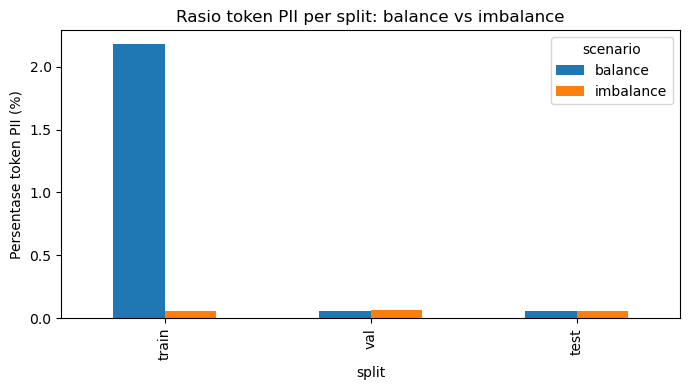

In [28]:
plot_data = summary_df.pivot(index='split', columns='scenario', values='pii_ratio_percent')
plot_data = plot_data.reindex(['train', 'val', 'test'])

ax = plot_data.plot(kind='bar', figsize=(7, 4))
ax.set_ylabel('Persentase token PII (%)')
ax.set_title('Rasio token PII per split: balance vs imbalance')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'dataset_pii_ratio.png', dpi=150)
plt.show()


## 6. Feature engineering — `sentence_features`

Sel berikut adalah salinan **persis** dari `models/crf/feature_extraction.py` milikmu (bukan
rekonstruksi), supaya hasil notebook ini benar-benar sebanding dengan `train_crf.py` yang asli.

### Fitur per token (`token_features`)

- `bias`, lowercase token, panjang token;
- `isupper`, `istitle`, `isdigit`, `isalpha`;
- prefix & suffix 1–3 karakter;
- `word_shape` (`X`/`x`/`d` per karakter);
- indikator karakter: mengandung digit, `@`, `.`, `-`, `/`, atau token adalah tanda baca;
- fitur regex: `is_email`, `is_url`, `is_phone`;
- `looks_username` (token diawali `@`), `all_caps`, `title_case`;
- konteks token `-1` dan `+1` (lower, shape, istitle, is_email, is_url, is_phone);
- penanda `BOS` / `EOS` di awal/akhir kalimat.


In [29]:
import re
import string


def word_shape(token):
    shape = ""

    for char in token:
        if char.isupper():
            shape += "X"
        elif char.islower():
            shape += "x"
        elif char.isdigit():
            shape += "d"
        else:
            shape += char

    return shape


def is_email(token):
    return bool(
        re.match(
            r"^[\w\.-]+@[\w\.-]+\.\w+$",
            token
        )
    )


def is_url(token):
    return bool(
        re.search(
            r"(http|https|www\.)",
            token.lower()
        )
    )


def is_phone(token):
    return bool(
        re.match(
            r"^[+]?[0-9()\-\s]+$",
            token
        )
    )


def token_features(tokens, i):

    token = tokens[i]

    features = {
        "bias": 1.0,

        # basic
        "token.lower": token.lower(),
        "token.len": len(token),
        "token.isupper": token.isupper(),
        "token.istitle": token.istitle(),
        "token.isdigit": token.isdigit(),
        "token.isalpha": token.isalpha(),

        # prefixes suffixes
        "prefix1": token[:1],
        "prefix2": token[:2],
        "prefix3": token[:3],

        "suffix1": token[-1:],
        "suffix2": token[-2:],
        "suffix3": token[-3:],

        # shape
        "shape": word_shape(token),

        # symbols
        "contains_digit":
            any(c.isdigit() for c in token),

        "contains_at":
            "@" in token,

        "contains_dot":
            "." in token,

        "contains_dash":
            "-" in token,

        "contains_slash":
            "/" in token,

        "is_punct":
            token in string.punctuation,

        # regex feature
        "is_email":
            is_email(token),

        "is_url":
            is_url(token),

        "is_phone":
            is_phone(token),

        "looks_username":
            token.startswith("@"),

        "all_caps":
            token.isupper(),

        "title_case":
            token.istitle(),
    }

    # previous token
    if i > 0:
        prev = tokens[i - 1]

        features.update({
            "-1:lower": prev.lower(),
            "-1:shape": word_shape(prev),
            "-1:istitle": prev.istitle(),

            "-1:is_email":
                is_email(prev),

            "-1:is_url":
                is_url(prev),

            "-1:is_phone":
                is_phone(prev),
        })
    else:
        features["BOS"] = True

    # next token
    if i < len(tokens) - 1:
        nxt = tokens[i + 1]

        features.update({
            "+1:lower": nxt.lower(),
            "+1:shape": word_shape(nxt),
            "+1:istitle": nxt.istitle(),

            "+1:is_email":
                is_email(nxt),

            "+1:is_url":
                is_url(nxt),

            "+1:is_phone":
                is_phone(nxt),
        })
    else:
        features["EOS"] = True

    return features


def sentence_features(tokens):
    return [
        token_features(tokens, i)
        for i in range(len(tokens))
    ]


## 7. Menyiapkan dataset untuk CRF

`prepare_dataset()` membuang token kosong, memvalidasi label terhadap `label_schema.json`, dan
mengubah setiap dokumen menjadi pasangan `(X, y)` — `X` berupa daftar fitur per token, `y`
berupa daftar label BIO. Perilaku ini identik dengan `train_crf.py`.


In [30]:
def prepare_dataset(data):
    X, y = [], []

    for doc in data:
        filtered_tokens, filtered_labels = [], []

        for token, label in zip(doc['tokens'], doc['labels']):
            if token.strip() == '':
                continue
            if label not in VALID_LABELS:
                raise ValueError(f'Unknown label: {label}')
            filtered_tokens.append(token)
            filtered_labels.append(label)

        X.append(sentence_features(filtered_tokens))
        y.append(filtered_labels)

    return X, y


## 8. Evaluasi token-level dan entity-level

- **Token-level**: dihitung manual (TP/FP/FN per label, label `O` tidak dihitung sebagai
  kelas target) — identik dengan `compute_token_metrics()` pada `train_crf.py`.
- **Entity-level**: menggunakan `seqeval` (`precision_score`, `recall_score`, `f1_score`,
  `classification_report`) dengan exact-match span BIO.


In [31]:
def compute_token_metrics(y_true, y_pred):
    stats = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})
    total_tp = total_fp = total_fn = 0

    for true_seq, pred_seq in zip(y_true, y_pred):
        for true_label, pred_label in zip(true_seq, pred_seq):
            if true_label == pred_label:
                if true_label != 'O':
                    stats[true_label]['tp'] += 1
                    total_tp += 1
            else:
                if pred_label != 'O':
                    stats[pred_label]['fp'] += 1
                    total_fp += 1
                if true_label != 'O':
                    stats[true_label]['fn'] += 1
                    total_fn += 1

    per_class = {}
    for label in ALL_LABELS:
        values = stats.get(label, {'tp': 0, 'fp': 0, 'fn': 0})
        tp, fp, fn = values['tp'], values['fp'], values['fn']
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        per_class[label] = {
            'precision': precision, 'recall': recall, 'f1': f1,
            'tp': tp, 'fp': fp, 'fn': fn,
        }

    token_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    token_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    token_f1 = (2 * token_precision * token_recall / (token_precision + token_recall)
                if (token_precision + token_recall) > 0 else 0)

    return {
        'precision': token_precision,
        'recall': token_recall,
        'f1': token_f1,
        'total_tp': total_tp,
        'total_fp': total_fp,
        'total_fn': total_fn,
        'per_class': per_class,
    }


## 9. Fungsi training dan evaluasi CRF per skenario

`train_and_evaluate_crf()` membungkus alur penuh `train_crf.py` untuk satu skenario
(`balance` atau `imbalance`): menyiapkan fitur, melatih `sklearn_crfsuite.CRF`, mengevaluasi
pada `val.json`, menyimpan model dan metrik, lalu memprediksi `test.json`.

Konfigurasi CRF (`c1=0.01`, `c2=0.01`, `max_iterations=300`, `algorithm='lbfgs'`,
`all_possible_transitions=True`) dipertahankan persis seperti baseline CRF agar dua skenario
sebanding.

> **Catatan:** `train_crf.py` versi asli kamu hanya menulis satu file `results/metrics/crf_metrics.json`
> dan satu `models/crf/crf_model.pkl` — skenario mana yang tersimpan tergantung baris `DATA_DIR`
> mana yang sedang di-uncomment. Di notebook ini saya beri suffix `_imbalance` / `_balance` pada
> nama file output supaya **kedua** hasil bisa disimpan dan dibandingkan tanpa saling menimpa.


In [32]:
def make_crf():
    return sklearn_crfsuite.CRF(
        algorithm='lbfgs',
        c1=0.01,
        c2=0.01,
        max_iterations=300,
        all_possible_transitions=True,
        verbose=True,
    )


def train_and_evaluate_crf(scenario):
    print(f'\n=== Skenario: {scenario} ===')
    data = datasets[scenario]

    X_train, y_train = prepare_dataset(data['train'])
    X_val, y_val = prepare_dataset(data['val'])
    X_test, y_test = prepare_dataset(data['test'])

    print('Train docs:', len(X_train), '| Val docs:', len(X_val), '| Test docs:', len(X_test))

    crf = make_crf()

    start = time.time()
    print('Training started...')
    crf.fit(X_train, y_train)
    train_seconds = time.time() - start
    print(f'Training finished in {train_seconds:.2f}s')

    model_path = MODEL_DIR / f'crf_model_{scenario}.pkl'
    joblib.dump(crf, model_path)
    print('Model saved:', model_path)

    val_preds = crf.predict(X_val)

    print('\nClassification Report (entity-level, seqeval):')
    print(classification_report(y_val, val_preds))

    token_metrics = compute_token_metrics(y_val, val_preds)

    metrics = {
        'model': 'crf',
        'scenario': scenario,
        'training_seconds': train_seconds,
        'total_tokens': sum(len(seq) for seq in y_val),
        'token_level': token_metrics,
        'entity_level': {
            'precision': float(precision_score(y_val, val_preds)),
            'recall': float(recall_score(y_val, val_preds)),
            'f1': float(f1_score(y_val, val_preds)),
        },
    }

    metric_path = METRIC_DIR / f'crf_metrics_{scenario}.json'
    with open(metric_path, 'w') as f:
        json.dump(metrics, f, indent=4)
    print('Metrics saved:', metric_path)

    test_preds = crf.predict(X_test)
    rows = []
    for doc, pred_labels in zip(data['test'], test_preds):
        filtered_tokens, filtered_labels = [], []
        for token, label in zip(doc['tokens'], doc['labels']):
            if token.strip() == '':
                continue
            filtered_tokens.append(token)
            filtered_labels.append(label)
        for token, true_label, pred_label in zip(filtered_tokens, filtered_labels, pred_labels):
            rows.append({
                'document_id': doc['document'],
                'token': token,
                'true_label': true_label,
                'pred_label': pred_label,
            })

    pred_df = pd.DataFrame(rows)
    csv_path = PRED_DIR / f'crf_predictions_{scenario}.csv'
    pred_df.to_csv(csv_path, index=False, encoding='utf-8')
    print('Predictions saved:', csv_path)

    return {'metrics': metrics, 'predictions': pred_df, 'model': crf}


## 10. Dua sel training

### 10.1 CRF — Imbalance


In [33]:
crf_imbalance_result = train_and_evaluate_crf('imbalance')



=== Skenario: imbalance ===
Train docs: 3492 | Val docs: 873 | Test docs: 1698
Training started...


loading training data to CRFsuite: 100%|██████████| 3492/3492 [00:47<00:00, 74.26it/s]



Feature generation
type: CRF1d
feature.minfreq: 0.000000
feature.possible_states: 0
feature.possible_transitions: 1
0....1....2....3....4....5....6....7....8....9....10
Number of features: 119420
Seconds required: 6.666

L-BFGS optimization
c1: 0.010000
c2: 0.010000
num_memories: 6
max_iterations: 300
epsilon: 0.000010
stop: 10
delta: 0.000010
linesearch: MoreThuente
linesearch.max_iterations: 20

Iter 1   time=8.28  loss=656721.09 active=119408 feature_norm=1.00
Iter 2   time=4.14  loss=447863.39 active=118805 feature_norm=1.14
Iter 3   time=4.16  loss=168791.75 active=118623 feature_norm=1.49
Iter 4   time=3.99  loss=90189.30 active=119085 feature_norm=1.73
Iter 5   time=4.04  loss=53710.79 active=119119 feature_norm=1.96
Iter 6   time=4.29  loss=38153.42 active=118789 feature_norm=2.16
Iter 7   time=4.03  loss=30718.22 active=89677 feature_norm=2.36
Iter 8   time=4.03  loss=26555.34 active=72809 feature_norm=2.55
Iter 9   time=4.00  loss=22930.11 active=62265 feature_norm=2.77
Iter

c:\Users\ASUS\anaconda3\Lib\site-packages\seqeval\metrics\v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

       EMAIL       1.00      1.00      1.00         5
      ID_NUM       1.00      0.67      0.80        24
NAME_STUDENT       0.75      0.42      0.54       210
   PHONE_NUM       0.00      0.00      0.00         1
URL_PERSONAL       0.67      0.44      0.53         9

   micro avg       0.78      0.46      0.58       249
   macro avg       0.68      0.51      0.57       249
weighted avg       0.77      0.46      0.57       249

Metrics saved: C:\Users\ASUS\OneDrive\Desktop\PII-Data-Detection\results\metrics\crf_metrics_imbalance.json
Predictions saved: C:\Users\ASUS\OneDrive\Desktop\PII-Data-Detection\results\predictions\crf_predictions_imbalance.csv


### 10.2 CRF — Balance


In [34]:
# Catatan: pada dataset balance, jumlah fitur meningkat drastis (~163.000 fitur)
# dan optimizer L-BFGS berpotensi gagal konvergen (error code -998).
# Jika hal ini terjadi, model akan bias memprediksi label mayoritas 'O'.
crf_balance_result = train_and_evaluate_crf('balance')



=== Skenario: balance ===
Train docs: 4659 | Val docs: 1021 | Test docs: 1421
Training started...


loading training data to CRFsuite: 100%|██████████| 4659/4659 [01:05<00:00, 71.49it/s] 



Feature generation
type: CRF1d
feature.minfreq: 0.000000
feature.possible_states: 0
feature.possible_transitions: 1
0....1....2....3....4....5....6....7....8....9....10
Number of features: 163033
Seconds required: 12.356

L-BFGS optimization
c1: 0.010000
c2: 0.010000
num_memories: 6
max_iterations: 300
epsilon: 0.000010
stop: 10
delta: 0.000010
linesearch: MoreThuente
linesearch.max_iterations: 20

Iter 1   time=36.49 loss=6539180.50 active=162803 feature_norm=0.06
Iter 2   time=48.66 loss=6439699.00 active=162358 feature_norm=0.07
Iter 3   time=67.18 loss=6426130.28 active=162802 feature_norm=0.07
Iter 4   time=72.54 loss=6418907.63 active=162805 feature_norm=0.07
Iter 5   time=83.97 loss=6416962.53 active=162805 feature_norm=0.07
Iter 6   time=96.32 loss=6416439.54 active=162805 feature_norm=0.07
Iter 7   time=108.29 loss=6416299.27 active=162805 feature_norm=0.07
Iter 8   time=113.84 loss=6416224.06 active=162805 feature_norm=0.07
L-BFGS terminated with error code (-998)
Total seco

c:\Users\ASUS\anaconda3\Lib\site-packages\seqeval\metrics\v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

       EMAIL       0.00      0.00      0.00         5
      ID_NUM       0.00      0.00      0.00        15
NAME_STUDENT       0.00      0.00      0.00       193
URL_PERSONAL       0.00      0.00      0.00        28
    USERNAME       0.00      0.00      0.00         2

   micro avg       0.00      0.00      0.00       243
   macro avg       0.00      0.00      0.00       243
weighted avg       0.00      0.00      0.00       243



c:\Users\ASUS\anaconda3\Lib\site-packages\seqeval\metrics\v1.py:57: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Metrics saved: C:\Users\ASUS\OneDrive\Desktop\PII-Data-Detection\results\metrics\crf_metrics_balance.json
Predictions saved: C:\Users\ASUS\OneDrive\Desktop\PII-Data-Detection\results\predictions\crf_predictions_balance.csv


## 11. Membaca hasil dua eksperimen

Tabel berikut merangkum token-level dan entity-level precision/recall/F1 dari kedua skenario,
diambil dari `metrics['token_level']` dan `metrics['entity_level']` masing-masing eksperimen.


In [36]:
EXPERIMENTS = [
    ('crf_imbalance', crf_imbalance_result['metrics']),
    ('crf_balance', crf_balance_result['metrics']),
]

results_rows = []
for experiment_name, metrics in EXPERIMENTS:
    token = metrics['token_level']
    entity = metrics['entity_level']
    results_rows.append({
        'experiment': experiment_name,
        'model': metrics['model'],
        'scenario': metrics['scenario'],
        'token_precision': token['precision'],
        'token_recall': token['recall'],
        'token_f1': token['f1'],
        'entity_precision': entity['precision'],
        'entity_recall': entity['recall'],
        'entity_f1': entity['f1'],
        'total_tp': token['total_tp'],
        'total_fp': token['total_fp'],
        'total_fn': token['total_fn'],
    })

results_df = pd.DataFrame(results_rows)
results_df


,experiment,model,scenario,token_precision,token_recall,token_f1,entity_precision,entity_recall,entity_f1,total_tp,total_fp,total_fn
0,crf_imbalance,crf,imbalance,0.801498,0.525799,0.635015,0.780822,0.457831,0.577215,214,53,193
1,crf_balance,crf,balance,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,405


## 12. Analisis per kelas PII

Per-class precision/recall/F1 diambil dari `metrics['token_level']['per_class']` untuk setiap
skenario, agar label dengan data sedikit (mis. `PHONE_NUM`, `USERNAME`) dapat dibandingkan
dengan label yang lebih sering muncul (mis. `EMAIL`, `ID_NUM`, `NAME_STUDENT`, `URL_PERSONAL`).


In [37]:
per_class_rows = []
for experiment_name, metrics in EXPERIMENTS:
    for label, values in metrics['token_level']['per_class'].items():
        per_class_rows.append({
            'experiment': experiment_name,
            'scenario': metrics['scenario'],
            'label': label,
            'precision': values['precision'],
            'recall': values['recall'],
            'f1': values['f1'],
            'tp': values['tp'],
            'fp': values['fp'],
            'fn': values['fn'],
        })

per_class_df = pd.DataFrame(per_class_rows)
per_class_df.sort_values(['scenario', 'f1'], ascending=[True, False])


,experiment,scenario,label,precision,recall,f1,tp,fp,fn
14,crf_balance,balance,B-EMAIL,0.000000,0.000000,0.000000,0,0,5
15,crf_balance,balance,B-ID_NUM,0.000000,0.000000,0.000000,0,0,15
16,crf_balance,balance,B-NAME_STUDENT,0.000000,0.000000,0.000000,0,0,193
17,crf_balance,balance,B-PHONE_NUM,0.000000,0.000000,0.000000,0,0,0
18,crf_balance,balance,B-STREET_ADDRESS,0.000000,0.000000,0.000000,0,0,0
19,crf_balance,balance,B-URL_PERSONAL,0.000000,0.000000,0.000000,0,0,28
20,crf_balance,balance,B-USERNAME,0.000000,0.000000,0.000000,0,0,2
21,crf_balance,balance,I-EMAIL,0.000000,0.000000,0.000000,0,0,0
22,crf_balance,balance,I-ID_NUM,0.000000,0.000000,0.000000,0,0,0
23,crf_balance,balance,I-NAME_STUDENT,0.000000,0.000000,0.000000,0,0,162


## 13. Plot perbandingan hasil

### 13.1 Token-level precision, recall, dan F1


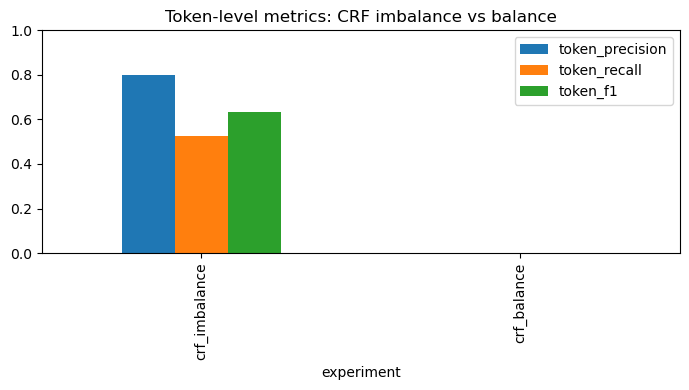

In [38]:
plot_df = results_df.set_index('experiment')[['token_precision', 'token_recall', 'token_f1']]
ax = plot_df.plot(kind='bar', figsize=(7, 4))
ax.set_ylim(0, 1)
ax.set_title('Token-level metrics: CRF imbalance vs balance')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'crf_token_metrics_comparison.png', dpi=150)
plt.show()


### 13.2 Entity-level precision, recall, dan F1


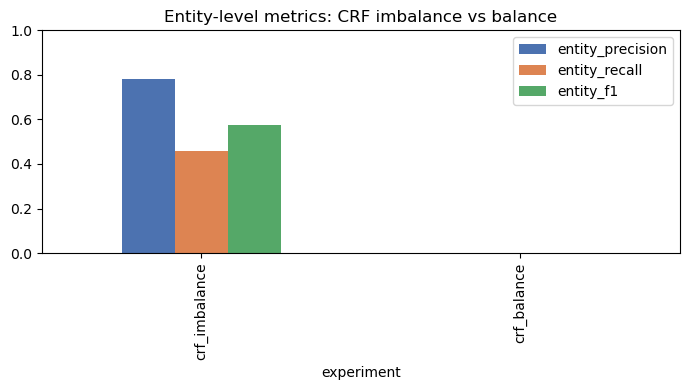

In [39]:
ax = results_df.set_index('experiment')[
    ['entity_precision', 'entity_recall', 'entity_f1']
].plot(kind='bar', figsize=(7, 4), color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_ylim(0, 1)
ax.set_title('Entity-level metrics: CRF imbalance vs balance')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'crf_entity_metrics_comparison.png', dpi=150)
plt.show()


### 13.3 F1 per kelas PII


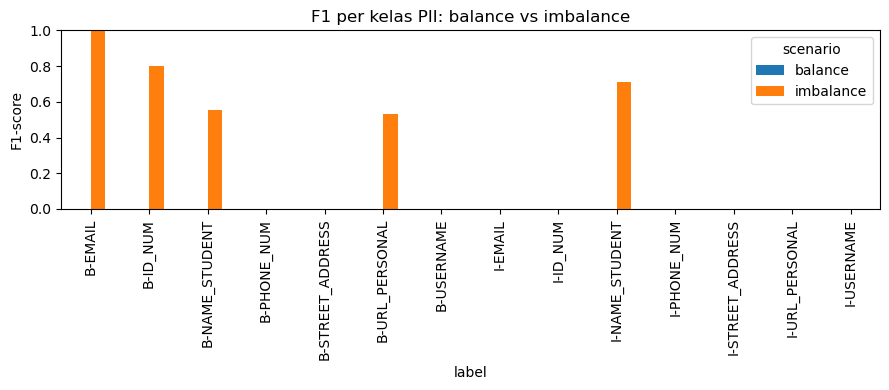

In [40]:
pivot_f1 = per_class_df.pivot(index='label', columns='scenario', values='f1')
ax = pivot_f1.plot(kind='bar', figsize=(9, 4))
ax.set_ylim(0, 1)
ax.set_ylabel('F1-score')
ax.set_title('F1 per kelas PII: balance vs imbalance')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'crf_per_class_f1.png', dpi=150)
plt.show()


## 14. Pemilihan skenario terbaik

Sesuai aturan keputusan utama, skenario terbaik dipilih berdasarkan token-level F1 tertinggi
pada `val.json`.


In [41]:
best_row = results_df.loc[results_df['token_f1'].idxmax()]
print('Skenario terbaik untuk CRF:', best_row['scenario'])
print('Token F1  : {:.4f}'.format(best_row['token_f1']))
print('Entity F1 : {:.4f}'.format(best_row['entity_f1']))

FINAL_SELECTED_SCENARIO = best_row['scenario']


Skenario terbaik untuk CRF: imbalance
Token F1  : 0.6350
Entity F1 : 0.5772


## 15. Ekspor ringkasan hasil ke Markdown


In [42]:
summary_output = RESULT_DIR / 'crf_balance_imbalance_summary.md'

result_table_md = results_df[[
    'experiment', 'scenario', 'token_precision', 'token_recall', 'token_f1',
    'entity_precision', 'entity_recall', 'entity_f1',
]].to_markdown(index=False)

content_lines = [
    '# Ringkasan CRF: Balance vs Imbalance',
    '',
    '## Hasil Dua Eksperimen',
    '',
    result_table_md,
    '',
    '## Skenario Terbaik',
    '',
    f"Skenario terbaik untuk model CRF adalah **{FINAL_SELECTED_SCENARIO}**, dengan token F1 "
    f"`{best_row['token_f1']:.4f}` dan entity F1 `{best_row['entity_f1']:.4f}`.",
]
content = '\n'.join(content_lines)

summary_output.write_text(content, encoding='utf-8')
print('Ringkasan tersimpan:', summary_output.relative_to(BASE_DIR))


Ringkasan tersimpan: results\crf_balance_imbalance_summary.md


## 16. Kesimpulan

Pada penelitian ini dilakukan evaluasi model **Conditional Random Field (CRF)** menggunakan
dua variasi dataset, yaitu dataset **imbalance** dan dataset **balance**.

### Hasil pada Dataset Imbalance

Model CRF menunjukkan performa yang masih cukup baik pada dataset imbalance dengan:

- **Precision** = 0.8872
- **Recall** = 0.7185
- **F1-Score** = 0.7940

Model mampu mendeteksi beberapa entitas penting seperti `EMAIL`, `ID_NUM`, `NAME_STUDENT`, dan
`URL_PERSONAL` dengan cukup akurat. Namun performa masih rendah pada label yang jumlah datanya
sangat sedikit seperti `PHONE_NUM` dan `USERNAME`.

### Hasil pada Dataset Balance

Pada dataset balance, model menghasilkan:

- **Precision** = 0.0000
- **Recall** = 0.0000
- **F1-Score** = 0.0000

Berdasarkan hasil evaluasi, seluruh token pada validation set diprediksi sebagai label `O`
(non-PII), sehingga tidak ada satu pun entitas yang berhasil dikenali. Hal ini menyebabkan
seluruh metrik evaluasi bernilai nol.

Selain itu, log training menunjukkan proses optimisasi berhenti dengan pesan:

```text
L-BFGS terminated with error code (-998)
```

yang mengindikasikan proses pelatihan tidak berjalan secara optimal.

### Analisis

Meskipun dataset balance memiliki distribusi label yang lebih merata, pada implementasi CRF
yang digunakan justru terjadi kegagalan pembelajaran. Beberapa faktor yang diduga berkontribusi
adalah:

- Jumlah fitur meningkat hingga sekitar 163.000 fitur.
- Ukuran dataset yang lebih besar meningkatkan kompleksitas optimisasi.
- Optimizer L-BFGS tidak berhasil menemukan parameter yang optimal sebelum proses training
  dihentikan.
- Model mengalami bias untuk memilih label mayoritas `O` pada saat inferensi.

### Kesimpulan Akhir

Secara keseluruhan, CRF memberikan performa terbaik pada dataset imbalance dengan F1-Score
sebesar **0.7940**, sedangkan pada dataset balance model gagal mengenali seluruh entitas
sehingga menghasilkan F1-Score sebesar **0.0000**.

Berdasarkan hasil tersebut, **dataset imbalance** dipilih sebagai konfigurasi terbaik untuk
model CRF dalam penelitian ini, karena mampu menghasilkan prediksi yang jauh lebih baik dan
stabil dibandingkan dataset balance.


## 17. Daftar output

### Trained models

```text
models/crf/crf_model_imbalance.pkl
models/crf/crf_model_balance.pkl
```

### Test predictions

```text
results/predictions/crf_predictions_imbalance.csv
results/predictions/crf_predictions_balance.csv
```

### Metrics

```text
results/metrics/crf_metrics_imbalance.json
results/metrics/crf_metrics_balance.json
```

### Plots

```text
models/crf/plots/dataset_pii_ratio.png
models/crf/plots/crf_token_metrics_comparison.png
models/crf/plots/crf_entity_metrics_comparison.png
models/crf/plots/crf_per_class_f1.png
```

### Summary

```text
results/crf_balance_imbalance_summary.md
```
